## Analisis Transaksi Pengalihan Hak atas Tanah dan/atau Bangunan (PHTB) dan PPh Final Menggunakan Data Analytics dan Machine Learning dengan Metode Regresi dan Anomaly Detection

## CRISP-DM Phase 1: Business Understanding


### Latar Belakang
Direktorat Jenderal Pajak (DJP) mengelola data transaksi Pengalihan Hak atas Tanah dan/atau Bangunan (PHTB) yang saat ini Surat Keterangan Validasi PPh Final atas transaksi tersebut langsung dikeluarkan tanpa didahului kegiatan Penelitian Kepatuhan Material. Salah satu tantangan utama adalah mendeteksi potensi **under-reporting harga transaksi** oleh Wajib Pajak.

### Tujuan
Membangun model Machine Learning untuk **memprediksi harga transaksi properti (HARGA)** berdasarkan karakteristik objek dan transaksi. Model ini dapat digunakan untuk:
1. **Deteksi anomali harga** — mengidentifikasi transaksi dengan harga yang jauh di bawah prediksi model
2. **Analisis kewajaran harga** — sebagai benchmark harga wajar berdasarkan luas tanah, bangunan, jenis objek, dll
3. **Profiling risiko** — mendukung pengawasan pajak

### Model yang Digunakan
1. **Linear Regression**
2. **Random Forest Regressor**
3. **Anomaly Detection**

## CRISP-DM Phase 2: Data Understanding

In [29]:
# Import Library yang dibutuhkan

import numpy as np
import pandas as pd
import datetime
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colors
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt, numpy as np
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import AgglomerativeClustering
from matplotlib.colors import ListedColormap
from sklearn import metrics
import warnings
import sys
if not sys.warnoptions:
    warnings.simplefilter("ignore")
np.random.seed(42)

In [30]:
# Baca file parquet untuk Data Analysis

# file_parquet_laptop = "C:/Users/user/OneDrive - Kemenkeu/Karejo/PJJ/10. Data Analytics/intro-python/MLFlow/4. PPHTB  999 - 15 10 2024.parquet"
file_parquet = "C:/Users/910223073/OneDrive - Kemenkeu/Karejo/PJJ/10. Data Analytics/intro-python/MLFlow/4. PPHTB  999 - 15 10 2024.parquet"
df_parquet = pd.read_parquet(file_parquet)
df_parquet.head()

,nama_wp,tempat_lapor,KPPADM_NOTARIS,KPPADM_PEMBELI,KPPADM_PENJUAL,NOMOR_SURAT,TGL_SURAT,CREATION_DATE,NPWP_NOTARIS,NAMA_NOTARIS,...,HARGA,JML_PPHFINAL_TERUTANG,NTPN,TGL_BAYAR,JUMLAH_BAYAR,e_pphtbnotaris,TAHUN_SURAT,TAHUN_TRANSAKSI,TAHUN_BAYAR,JENIS_OBJEK_PAJAK
0,CHOESNOEL AISYAH,None,626.0,nan,626.0,SKET-4707/PHTB/KPP.120703/2022,2022-10-11,11-OCT-22 09.34.12.891000 AM,640942785626000,ERNA TRI MOERHADIATI,...,600000000,"15,000,000.00",3AC663IED1J3LJ6C,2022-10-04,"15,000,000.00",Y,2022,2022,2022,Tanah dan Bangunan
1,IR.A.TOSSIN SUHARYA,None,416.0,29.0,73.0,SKET-6308/PHTB/KPP.081203/2023,2023-12-18,18-DEC-23 03.45.56.065000 PM,243267531416000,MOHAMAD ABROR,...,21000000,"525,000.00",2D1345BANL29RJ2K,2023-12-15,"525,000.00",Y,2023,2023,2023,Tanah Kosong
2,IR.A.TOSSIN SUHARYA,None,416.0,29.0,73.0,SKET-6278/PHTB/KPP.081203/2023,2023-12-18,18-DEC-23 03.06.29.978000 PM,243267531416000,MOHAMAD ABROR,...,252840000,"6,321,000.00",0D2A44ET7QA2K9DA,2023-12-15,"6,321,000.00",Y,2023,2023,2023,Tanah Kosong
3,IR.A.TOSSIN SUHARYA,None,416.0,29.0,73.0,SKET-6307/PHTB/KPP.081203/2023,2023-12-18,18-DEC-23 03.42.17.892000 PM,243267531416000,MOHAMAD ABROR,...,321000000,"8,025,000.00",61C174ET7QFSQGFC,2023-12-15,"8,025,000.00",Y,2023,2023,2023,Tanah Kosong
4,IR.A.TOSSIN SUHARYA,None,416.0,29.0,73.0,SKET-6226/PHTB/KPP.081203/2023,2023-12-15,15-DEC-23 03.33.00.106000 PM,243267531416000,MOHAMAD ABROR,...,180000000,"4,500,000.00",CB7872M285D2C1SR,2023-12-15,"4,500,000.00",Y,2023,2023,2023,Tanah Kosong


In [31]:
# 2.1 Gambaran Umum Dataset
print(f"Jumlah baris total : {df_parquet.shape[0]:,}")
print(f"Jumlah kolom total : {df_parquet.shape[1]}")
print(f"\nDistribusi Tahun Transaksi:")

distribusi_tahun = df_parquet['TAHUN_TRANSAKSI'].value_counts().sort_index(ascending=False)
print(distribusi_tahun.map('{:,}'.format))

Jumlah baris total : 8,966,277
Jumlah kolom total : 48

Distribusi Tahun Transaksi:
TAHUN_TRANSAKSI
2024    1,476,854
2023    2,048,853
2022    1,807,304
2021    1,456,417
2020    1,236,568
2019      780,391
2018      156,903
2017        1,602
2016          835
2015          111
2014           84
2013           85
2012           35
2011           29
2010           34
2009           18
2008           30
2007           24
2006           28
2005           25
2004           18
2003           16
2002           13
Name: count, dtype: object


In [32]:
# 2.2 Buat df_model dengan filter Tahun Transaksi 2020-2024
import pyarrow.parquet as pq
pd.options.display.float_format = '{:,.2f}'.format

df_model = df_parquet[df_parquet['TAHUN_TRANSAKSI'].between(2020, 2024)].copy()
print(f"Jumlah baris (2020-2024): {len(df_model):,}")
print(f"Jumlah kolom            : {len(df_model.columns)}")
print(f"Memory usage            : {df_model.memory_usage(deep=True).sum() / 1e6:.1f} MB")

# Statistik Deskriptif
kolom_numerik = ['LUAS_TANAH', 'LUAS_BANGUNAN', 'HARGA', 'JML_PPHFINAL_TERUTANG', 'JUMLAH_BAYAR', 'TARIF_PPH']
stats = df_model[kolom_numerik].describe()

print("\nStatistik Deskriptif (Format Ribuan):")
display(stats)

Jumlah baris (2020-2024): 8,025,996
Jumlah kolom            : 48
Memory usage            : 16678.4 MB

Statistik Deskriptif (Format Ribuan):


,LUAS_TANAH,LUAS_BANGUNAN,HARGA,JML_PPHFINAL_TERUTANG,JUMLAH_BAYAR,TARIF_PPH
count,"8,025,996.00","8,025,996.00","8,025,996.00","8,025,996.00","8,025,996.00","8,025,996.00"
mean,"2,650.81","5,381.59","616,602,364.84","17,810,652.31","6,482,622.36",2.74
std,"900,833.29","1,871,589.19","3,953,941,958.51","111,093,224.26","78,164,929.52",1.10
min,0.00,0.00,1.00,0.00,1.00,0.50
25%,60.00,17.84,"103,040,000.00","1,749,500.00","500,000.00",2.50
50%,84.00,36.00,"200,000,000.00","5,705,700.00","1,505,000.00",2.50
75%,151.00,77.00,"550,000,000.00","16,477,270.00","3,912,500.00",2.50
max,"1,180,350,000.00","910,000,000.00","3,500,000,000,000.00","87,500,000,000.00","87,500,000,000.00",5.00


In [33]:
# 2.3 Distribusi Kolom Kategorikal
print("JENIS_OBJEK_PAJAK:")
print(df_model['JENIS_OBJEK_PAJAK'].value_counts().map('{:,}'.format))

print("\nJENIS_PENGALIHAN:")
print(df_model['JENIS_PENGALIHAN'].value_counts().map('{:,}'.format))

print("\nJNS_PENJUAL:")
print(df_model['JNS_PENJUAL'].value_counts().map('{:,}'.format))

print("\nTARIF_PPH:")
print(df_model['TARIF_PPH'].value_counts().sort_index().map('{:,}'.format))

JENIS_OBJEK_PAJAK:
JENIS_OBJEK_PAJAK
Tanah dan Bangunan       5,494,793
Tanah Kosong             1,824,942
Apartemen/Rumah Susun      700,413
Data Tidak Valid             5,848
Name: count, dtype: object

JENIS_PENGALIHAN:
JENIS_PENGALIHAN
4          6,131,080
lainnya      934,861
3            813,338
PPJB          73,043
rss           66,569
KIK            1,235
kik               14
Name: count, dtype: object

JNS_PENJUAL:
JNS_PENJUAL
1BADAN       5,017,768
0OP          2,000,168
OP             793,359
BADAN          207,894
2                6,616
BENDAHARA          191
Name: count, dtype: object

TARIF_PPH:
TARIF_PPH
0.50          752
1.00      888,658
2.50    5,835,288
2.70            7
2.98           16
3.03            2
3.12           19
3.75            1
4.39           12
5.00    1,301,241
Name: count, dtype: object


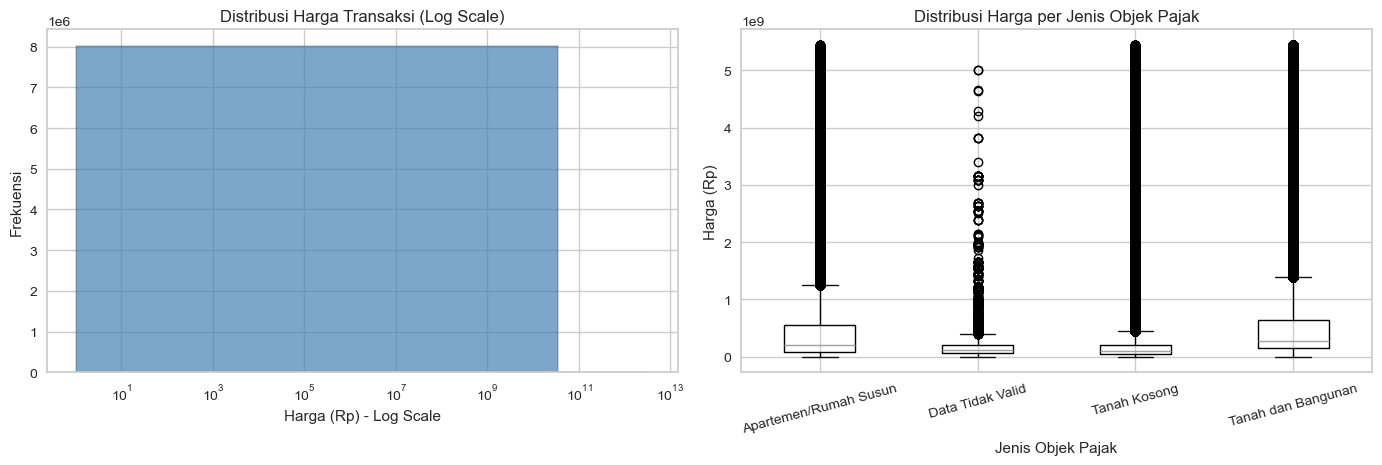

In [34]:
# 2.4 Visualisasi Distribusi Harga Transaksi (Log Scale)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribusi HARGA (log scale)
axes[0].hist(df_model['HARGA'][df_model['HARGA'] > 0], bins=100, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xscale('log')
axes[0].set_title('Distribusi Harga Transaksi (Log Scale)', fontsize=12)
axes[0].set_xlabel('Harga (Rp) - Log Scale')
axes[0].set_ylabel('Frekuensi')

# Boxplot HARGA per Jenis Objek
df_box = df_model[df_model['HARGA'].between(1, df_model['HARGA'].quantile(0.99))]
df_box.boxplot(column='HARGA', by='JENIS_OBJEK_PAJAK', ax=axes[1], vert=True)
axes[1].set_title('Distribusi Harga per Jenis Objek Pajak', fontsize=12)
axes[1].set_xlabel('Jenis Objek Pajak')
axes[1].set_ylabel('Harga (Rp)')
axes[1].tick_params(axis='x', rotation=15)
plt.suptitle('')

plt.tight_layout()
plt.show()

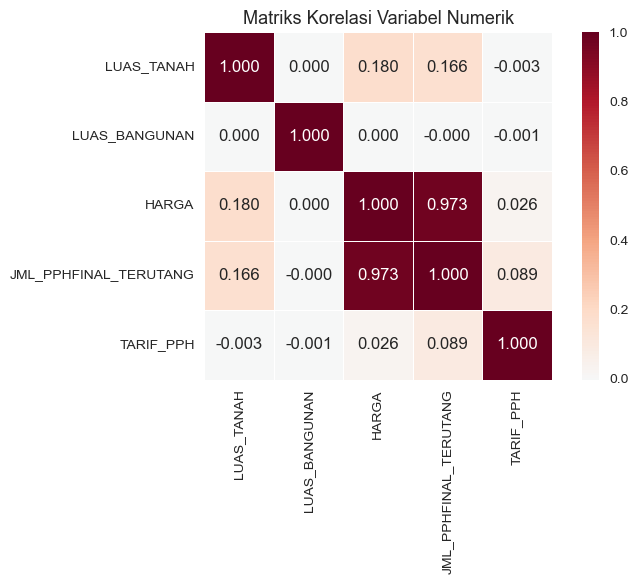

In [35]:
# 2.5 Korelasi antar Variabel Numerik
kolom_korelasi = ['LUAS_TANAH', 'LUAS_BANGUNAN', 'HARGA', 'JML_PPHFINAL_TERUTANG', 'TARIF_PPH']
# Sampling untuk hitung korelasi
corr_sample = df_model[kolom_korelasi].sample(n=100000, random_state=42)
corr_matrix = corr_sample.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r', center=0, 
            square=True, linewidths=0.5)
plt.title('Matriks Korelasi Variabel Numerik', fontsize=13)
plt.tight_layout()
plt.show()

## CRISP-DM Phase 3: Data Preparation

### Langkah-langkah:
1. Seleksi kolom yang relevan (target + features)
2. Pembersihan data: hapus missing values, data tidak valid, dan outlier ekstrem
3. Standardisasi kategori (mapping value yang inkonsisten)
4. Encoding variabel kategorikal
5. Sampling 3.000.000 baris
6. Train-test split (80:20)

### 3.1 Seleksi Kolom & Pembersihan Data

#### Target & Features
| Variabel | Peran | Deskripsi |
|---|---|---|
| **HARGA** | Target (y) | Harga transaksi pengalihan properti |
| LUAS_TANAH | Feature | Luas tanah (m²) |
| LUAS_BANGUNAN | Feature | Luas bangunan (m²) |
| TARIF_PPH | Feature | Tarif PPh Final yang diterapkan (%) |
| JENIS_PENGALIHAN | Feature | Jenis pengalihan (lainnya, rss, kik, PPJB, dll) |
| JENIS_OBJEK_PAJAK | Feature | Jenis objek (Tanah dan Bangunan, Tanah Kosong, Apartemen, dll) |
| JNS_PENJUAL | Feature | Jenis penjual (OP, BADAN, BENDAHARA) |
| TAHUN_TRANSAKSI | Feature | Tahun transaksi (2020-2024) |
| KPP_LOKASI_OBJEK | Feature | Kode KPP lokasi objek pajak

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Kolom yang digunakan
features_cat = ['JENIS_PENGALIHAN', 'JENIS_OBJEK_PAJAK', 'JNS_PENJUAL', 'KPP_LOKASI_OBJEK']
features_num = ['LUAS_TANAH', 'LUAS_BANGUNAN', 'TARIF_PPH', 'TAHUN_TRANSAKSI']
target = 'HARGA'

kolom_pakai = features_cat + features_num + [target]
df_model = df_model[kolom_pakai].copy()

print(f"Jumlah baris awal: {len(df_model):,}")

# Hapus missing values
df_model = df_model.dropna()
print(f"Setelah hapus missing: {len(df_model):,}")

# Hapus data tidak valid
df_model = df_model[df_model['JENIS_OBJEK_PAJAK'] != 'Data Tidak Valid']
print(f"Setelah hapus 'Data Tidak Valid': {len(df_model):,}")

# Hapus HARGA <= 0 dan LUAS_TANAH <= 0
df_model = df_model[(df_model['HARGA'] > 0) & (df_model['LUAS_TANAH'] > 0)]
print(f"Setelah hapus HARGA/LUAS_TANAH <= 0: {len(df_model):,}")

# Hapus outlier ekstrem menggunakan IQR pada HARGA
Q1 = df_model['HARGA'].quantile(0.01)
Q3 = df_model['HARGA'].quantile(0.99)
df_model = df_model[(df_model['HARGA'] >= Q1) & (df_model['HARGA'] <= Q3)]
print(f"Setelah hapus outlier HARGA (1%-99%): {len(df_model):,}")

# Hapus outlier ekstrem LUAS_TANAH
Q1_lt = df_model['LUAS_TANAH'].quantile(0.01)
Q3_lt = df_model['LUAS_TANAH'].quantile(0.99)
df_model = df_model[(df_model['LUAS_TANAH'] >= Q1_lt) & (df_model['LUAS_TANAH'] <= Q3_lt)]
print(f"Setelah hapus outlier LUAS_TANAH (1%-99%): {len(df_model):,}")

Jumlah baris awal: 8,025,996
Setelah hapus missing: 8,020,140
Setelah hapus 'Data Tidak Valid': 8,014,292
Setelah hapus HARGA/LUAS_TANAH <= 0: 7,313,880
Setelah hapus outlier HARGA (1%-99%): 7,167,605
Setelah hapus outlier LUAS_TANAH (1%-99%): 7,033,706


### 3.2 Standardisasi Kategori

In [37]:
# JNS_PENJUAL: '0OP' -> 'OP', '1BADAN' -> 'BADAN', '2' -> 'LAINNYA'
jns_penjual_map = {
    'OP': 'OP', 
    '0OP': 'OP', 
    'BADAN': 'BADAN', 
    '1BADAN': 'BADAN', 
    'BENDAHARA': 'BENDAHARA',
    '2': 'LAINNYA'
}
df_model['JNS_PENJUAL'] = df_model['JNS_PENJUAL'].map(jns_penjual_map).fillna('LAINNYA')

# JENIS_PENGALIHAN: '3' & '4' adalah kode jenis pengalihan, 'kik'/'KIK' distandardisasi
jp_map = {
    'lainnya': 'LAINNYA',
    'rss': 'RSS',
    'kik': 'KIK',
    'KIK': 'KIK',
    'PPJB': 'PPJB',
    '3': 'JUAL_BELI',      # Kode 3 = Jual Beli
    '4': 'JUAL_BELI_UMUM'  # Kode 4 = Jual Beli Umum
}
df_model['JENIS_PENGALIHAN'] = df_model['JENIS_PENGALIHAN'].map(jp_map).fillna('LAINNYA')

print("Distribusi setelah standardisasi:")
print("\nJNS_PENJUAL:")
print(df_model['JNS_PENJUAL'].value_counts().map('{:,}'.format))

print("\nJENIS_PENGALIHAN:")
print(df_model['JENIS_PENGALIHAN'].value_counts().map('{:,}'.format))

print("\nJENIS_OBJEK_PAJAK:")
print(df_model['JENIS_OBJEK_PAJAK'].value_counts().map('{:,}'.format))

print(f"\nKPP_LOKASI_OBJEK:")
print(f"  Jumlah KPP unik : {df_model['KPP_LOKASI_OBJEK'].nunique():,}")
print(df_model['KPP_LOKASI_OBJEK'].value_counts().head(10).map('{:,}'.format))

Distribusi setelah standardisasi:

JNS_PENJUAL:
JNS_PENJUAL
BADAN        4,378,455
OP           2,649,210
LAINNYA          5,863
BENDAHARA          178
Name: count, dtype: object

JENIS_PENGALIHAN:
JENIS_PENGALIHAN
JUAL_BELI_UMUM    5,260,704
LAINNYA             870,162
JUAL_BELI           769,581
PPJB                 66,464
RSS                  65,636
KIK                   1,159
Name: count, dtype: object

JENIS_OBJEK_PAJAK:
JENIS_OBJEK_PAJAK
Tanah dan Bangunan    5,331,337
Tanah Kosong          1,702,369
Name: count, dtype: object

KPP_LOKASI_OBJEK:
  Jumlah KPP unik : 320
KPP_LOKASI_OBJEK
451.0    361,718
418.0    306,293
435.0    198,867
403.0    183,165
225.0    156,010
434.0    150,416
47.0     141,734
44.0     122,758
36.0     120,064
604.0    113,638
Name: count, dtype: object


### 3.3 Sampling 3.000.000 baris & Encoding

In [38]:
# Sampling berdasarkan TAHUN_TRANSAKSI
SAMPLE_SIZE = 3_000_000

# Hitung proporsi per tahun
proporsi = df_model['TAHUN_TRANSAKSI'].value_counts(normalize=True)
print("Proporsi per tahun:")
print(proporsi.sort_index())

# Sampling proporsional per tahun
sampled_list = []
for tahun, group in df_model.groupby('TAHUN_TRANSAKSI'):
    n_sample = int(SAMPLE_SIZE * len(group) / len(df_model))
    sampled_list.append(group.sample(n=n_sample, random_state=42))

df_sampled = pd.concat(sampled_list).reset_index(drop=True)
print(f"\nJumlah sampel: {len(df_sampled):,}")
print(df_sampled['TAHUN_TRANSAKSI'].value_counts().sort_index().map('{:,}'.format))

# Label Encoding untuk variabel kategorikal
le_dict = {}
for col in features_cat:
    le = LabelEncoder()
    df_sampled[col] = le.fit_transform(df_sampled[col])
    le_dict[col] = le
    print(f"\n{col} encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")

Proporsi per tahun:
TAHUN_TRANSAKSI
2020   0.16
2021   0.19
2022   0.22
2023   0.25
2024   0.18
Name: proportion, dtype: Float64

Jumlah sampel: 2,999,997
TAHUN_TRANSAKSI
2020    479,503
2021    564,752
2022    669,155
2023    745,724
2024    540,863
Name: count, dtype: object

JENIS_PENGALIHAN encoding: {'JUAL_BELI': np.int64(0), 'JUAL_BELI_UMUM': np.int64(1), 'KIK': np.int64(2), 'LAINNYA': np.int64(3), 'PPJB': np.int64(4), 'RSS': np.int64(5)}

JENIS_OBJEK_PAJAK encoding: {'Tanah Kosong': np.int64(0), 'Tanah dan Bangunan': np.int64(1)}

JNS_PENJUAL encoding: {'BADAN': np.int64(0), 'BENDAHARA': np.int64(1), 'LAINNYA': np.int64(2), 'OP': np.int64(3)}

KPP_LOKASI_OBJEK encoding: {'1.0': np.int64(0), '101.0': np.int64(1), '102.0': np.int64(2), '103.0': np.int64(3), '104.0': np.int64(4), '105.0': np.int64(5), '106.0': np.int64(6), '107.0': np.int64(7), '108.0': np.int64(8), '11.0': np.int64(9), '111.0': np.int64(10), '112.0': np.int64(11), '113.0': np.int64(12), '114.0': np.int64(13), '115

In [39]:
# 3.4 Pisahkan Features (X) dan Target (y)
from sklearn.preprocessing import StandardScaler

X = df_sampled[features_cat + features_num]
y = df_sampled[target]

# Train-Test Split (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling fitur numerik
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[features_num] = scaler.fit_transform(X_train[features_num])
X_test_scaled[features_num] = scaler.transform(X_test[features_num])

print(f"X_train shape: {X_train_scaled.shape}")
print(f"X_test shape : {X_test_scaled.shape}")
print(f"y_train range: {y_train.min():,.0f} - {y_train.max():,.0f}")
print(f"y_test range : {y_test.min():,.0f} - {y_test.max():,.0f}")

X_train shape: (2399997, 8)
X_test shape : (600000, 8)
y_train range: 6,847,000 - 5,548,414,540
y_test range : 6,850,000 - 5,548,414,540


## CRISP-DM Phase 4: Modeling (Regression & Anomaly Detection)

### 4.1 Model 1: Linear Regression

In [40]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time

print("=" * 60)
print("MODEL 1: LINEAR REGRESSION")
print("=" * 60)

start_time = time.time()
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_train_time = time.time() - start_time

# Prediksi
y_pred_lr = lr_model.predict(X_test_scaled)

# Evaluasi
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_r2 = r2_score(y_test, y_pred_lr)
lr_mape = np.mean(np.abs((y_test - y_pred_lr) / y_test)) * 100

print(f"Training Time  : {lr_train_time:.2f} detik")
print(f"MAE            : Rp {lr_mae:,.0f}")
print(f"RMSE           : Rp {lr_rmse:,.0f}")
print(f"R² Score       : {lr_r2:.4f}")
print(f"MAPE           : {lr_mape:.2f}%")

# Koefisien
print(f"\nKoefisien Model:")
for feat, coef in zip(features_cat + features_num, lr_model.coef_):
    print(f"  {feat:25s}: {coef:>15,.2f}")
print(f"  {'Intercept':25s}: {lr_model.intercept_:>15,.2f}")

MODEL 1: LINEAR REGRESSION
Training Time  : 0.68 detik
MAE            : Rp 403,150,636
RMSE           : Rp 661,844,217
R² Score       : 0.0732
MAPE           : 277.71%

Koefisien Model:
  JENIS_PENGALIHAN         :   22,922,471.86
  JENIS_OBJEK_PAJAK        :  285,952,638.33
  JNS_PENJUAL              :  -49,792,311.07
  KPP_LOKASI_OBJEK         :     -161,243.73
  LUAS_TANAH               :   92,670,205.14
  LUAS_BANGUNAN            :     -777,259.33
  TARIF_PPH                :   87,695,193.26
  TAHUN_TRANSAKSI          :   -6,096,453.16
  Intercept                :  313,048,543.28


### 4.2 Model 2: Random Forest Regressor

In [41]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time

print("=" * 60)
print("MODEL 2: RANDOM FOREST REGRESSOR")
print("=" * 60)
print("Training dimulai... (estimasi beberapa menit)")

start_time = time.time()
rf_model = RandomForestRegressor(
    n_estimators=100,      
    max_depth=15,          
    min_samples_split=10,  
    min_samples_leaf=5,    
    n_jobs=-1,             
    random_state=42,
    verbose=1
)
rf_model.fit(X_train_scaled, y_train)
rf_train_time = time.time() - start_time

# Prediksi
y_pred_rf = rf_model.predict(X_test_scaled)

# Evaluasi
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)
rf_mape = np.mean(np.abs((y_test - y_pred_rf) / y_test)) * 100

print(f"\nTraining Time  : {rf_train_time:.2f} detik")
print(f"MAE            : Rp {rf_mae:,.0f}")
print(f"RMSE           : Rp {rf_rmse:,.0f}")
print(f"R² Score       : {rf_r2:.4f}")
print(f"MAPE           : {rf_mape:.2f}%")

MODEL 2: RANDOM FOREST REGRESSOR
Training dimulai... (estimasi beberapa menit)


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 6 concurrent workers.
[Parallel(n_jobs=-1)]: Done  38 tasks      | elapsed:  2.5min
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  6.0min finished
[Parallel(n_jobs=6)]: Using backend ThreadingBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done  38 tasks      | elapsed:    0.6s



Training Time  : 360.56 detik
MAE            : Rp 208,044,395
RMSE           : Rp 396,924,103
R² Score       : 0.6667
MAPE           : 124.83%


[Parallel(n_jobs=6)]: Done 100 out of 100 | elapsed:    1.7s finished


### 4.3 Anomaly Detection

[Parallel(n_jobs=6)]: Using backend ThreadingBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done  38 tasks      | elapsed:    0.7s
[Parallel(n_jobs=6)]: Done 100 out of 100 | elapsed:    1.8s finished


---------HASIL DETEKSI ANOMALI HARGA---------
Metode Digunakan    : 1.5-Sigma
Mean (Data Bersih)  :          -11.56%
Std Dev (Data Bersih):           37.38%
Threshold Deteksi   :          -67.63%
---------------------------------------------
Jumlah Transaksi Under-Valued: 81,276 dari 600,000
Persentase Temuan   : 13.55%


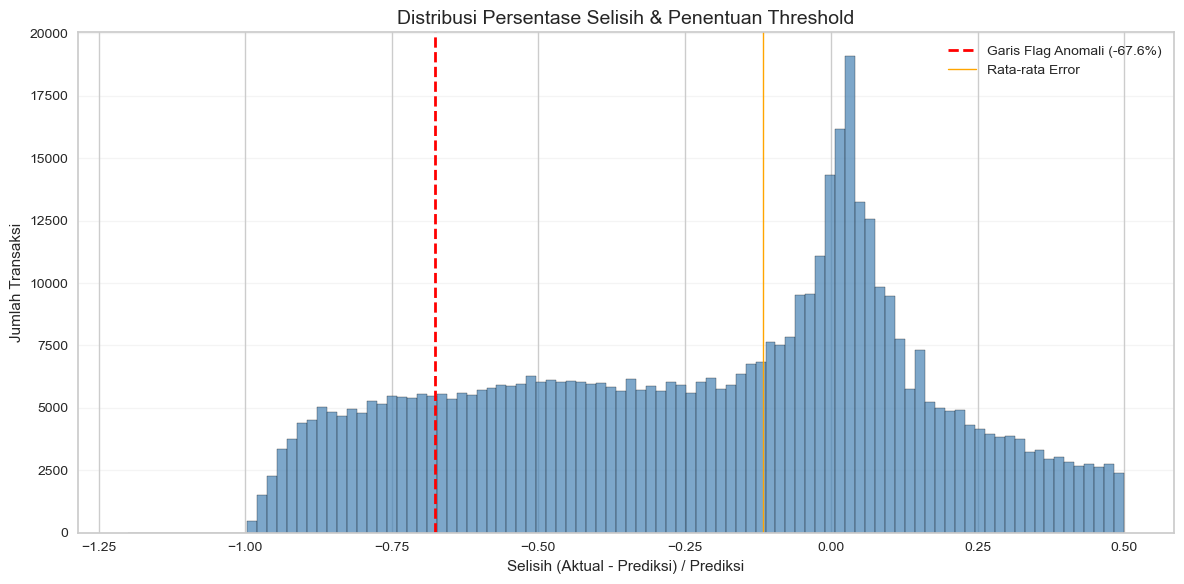

In [42]:
# 1. Hitung Prediksi
y_pred_all = rf_model.predict(X_test_scaled)

# 2. Hitung residual persentase (Aktual - Prediksi) / Prediksi
residual_pct = (y_test - y_pred_all) / np.where(y_pred_all == 0, 1, y_pred_all)

# 3. Filter data "Bersih" untuk menghitung statistik yang tidak terganggu outlier
mask_wajar = residual_pct.between(-0.8, 0.8)
residual_clean = residual_pct[mask_wajar]

mean_clean = residual_clean.mean()
std_clean = residual_clean.std()

# 4. Penentuan Threshold

threshold_pct = mean_clean - (1.5 * std_clean)

# Batas Pengaman (Hard Limit): 
# Jika harga dilaporkan < 50% harga pasar, itu sudah pasti anomali di mata pajak.
# Kita ambil mana yang lebih moderat antara statistik vs hard limit.
if threshold_pct < -0.90:
    threshold_pct = -0.60 # Default ke 60% jika statistik terlalu lebar
    tipe_threshold = "Batas Statis (60%)"
else:
    tipe_threshold = "1.5-Sigma"

# 5. Flag anomali pada seluruh dataset
anomali_mask = residual_pct < threshold_pct
n_anomali = anomali_mask.sum()

print(f"{'HASIL DETEKSI ANOMALI HARGA':-^45}")
print(f"Metode Digunakan    : {tipe_threshold}")
print(f"Mean (Data Bersih)  : {mean_clean*100:>15.2f}%")
print(f"Std Dev (Data Bersih): {std_clean*100:>15.2f}%")
print(f"Threshold Deteksi   : {threshold_pct*100:>15.2f}%")
print("-" * 45)
print(f"Jumlah Transaksi Under-Valued: {n_anomali:,} dari {len(y_test):,}")
print(f"Persentase Temuan   : {n_anomali/len(y_test)*100:.2f}%")

# 6. Visualisasi
plt.figure(figsize=(12, 6))
# Zoom histogram pada area krusial (-1.2 sampai 0.5)
plt.hist(residual_pct, bins=100, range=(-1.2, 0.5), color='steelblue', edgecolor='black', alpha=0.7)

plt.axvline(x=threshold_pct, color='red', linestyle='--', linewidth=2, 
            label=f'Garis Flag Anomali ({threshold_pct*100:.1f}%)')
plt.axvline(x=mean_clean, color='orange', linestyle='-', linewidth=1, label='Rata-rata Error')

plt.title('Distribusi Persentase Selisih & Penentuan Threshold', fontsize=14)
plt.xlabel('Selisih (Aktual - Prediksi) / Prediksi')
plt.ylabel('Jumlah Transaksi')
plt.legend()
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

## CRISP-DM Phase 5: Evaluation

### 5.1 Perbandingan Metrik Kedua Model

In [43]:
print("=" * 70)
print("PERBANDINGAN MODEL")
print("=" * 70)

comparison = pd.DataFrame({
    'Metrik': ['MAE (Rp)', 'RMSE (Rp)', 'R² Score', 'MAPE (%)', 'Training Time (s)'],
    'Linear Regression': [f'{lr_mae:,.0f}', f'{lr_rmse:,.0f}', f'{lr_r2:.4f}', f'{lr_mape:.2f}', f'{lr_train_time:.2f}'],
    'Random Forest': [f'{rf_mae:,.0f}', f'{rf_rmse:,.0f}', f'{rf_r2:.4f}', f'{rf_mape:.2f}', f'{rf_train_time:.2f}']
})
comparison.set_index('Metrik', inplace=True)
comparison

PERBANDINGAN MODEL


,Linear Regression,Random Forest
Metrik,,
MAE (Rp),"403,150,636","208,044,395"
RMSE (Rp),"661,844,217","396,924,103"
R² Score,0.0732,0.6667
MAPE (%),277.71,124.83
Training Time (s),0.68,360.56


### 5.2 Visualisasi: Actual vs Predicted (kedua model)

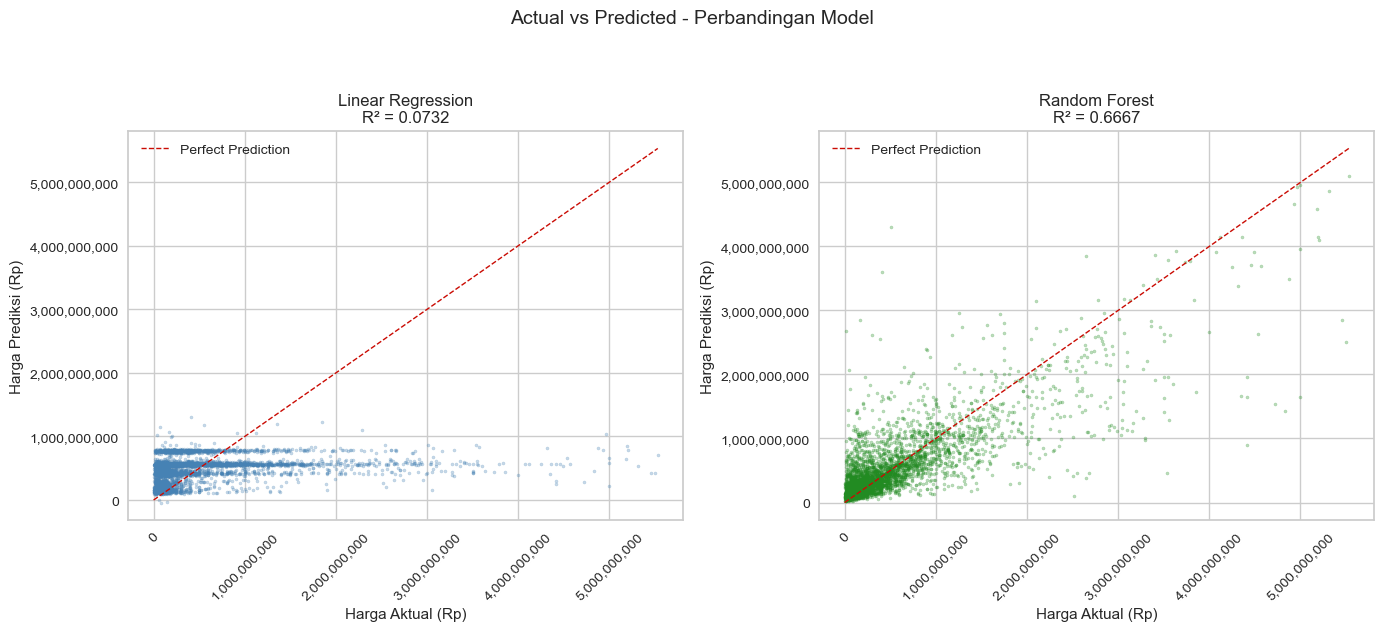

In [48]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick # Import library untuk formatting axis
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Sampling 5000 titik untuk visualisasi (lebih ringan)
idx = np.random.choice(len(y_test), size=min(5000, len(y_test)), replace=False)

# 1. Linear Regression
axes[0].scatter(y_test.values[idx], y_pred_lr[idx], alpha=0.3, s=5, color='steelblue')
max_val = max(y_test.values[idx].max(), y_pred_lr[idx].max())
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=1, label='Perfect Prediction')
axes[0].set_xlabel('Harga Aktual (Rp)')
axes[0].set_ylabel('Harga Prediksi (Rp)')
axes[0].set_title(f'Linear Regression\nR² = {lr_r2:.4f}', fontsize=12)
axes[0].legend()

# Menambahkan pemisah ribuan pada Linear Regression
axes[0].xaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
axes[0].yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

# 2. Random Forest
axes[1].scatter(y_test.values[idx], y_pred_rf[idx], alpha=0.3, s=5, color='forestgreen')
axes[1].plot([0, max_val], [0, max_val], 'r--', linewidth=1, label='Perfect Prediction')
axes[1].set_xlabel('Harga Aktual (Rp)')
axes[1].set_ylabel('Harga Prediksi (Rp)')
axes[1].set_title(f'Random Forest\nR² = {rf_r2:.4f}', fontsize=12)
axes[1].legend()

# Menambahkan pemisah ribuan pada Random Forest
axes[1].xaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
axes[1].yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

# Memutar label axis agar tidak bertabrakan jika angkanya sangat panjang
plt.setp(axes[0].get_xticklabels(), rotation=45)
plt.setp(axes[1].get_xticklabels(), rotation=45)

plt.suptitle('Actual vs Predicted - Perbandingan Model', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

### 5.3 Distribusi Residual (Error) kedua model

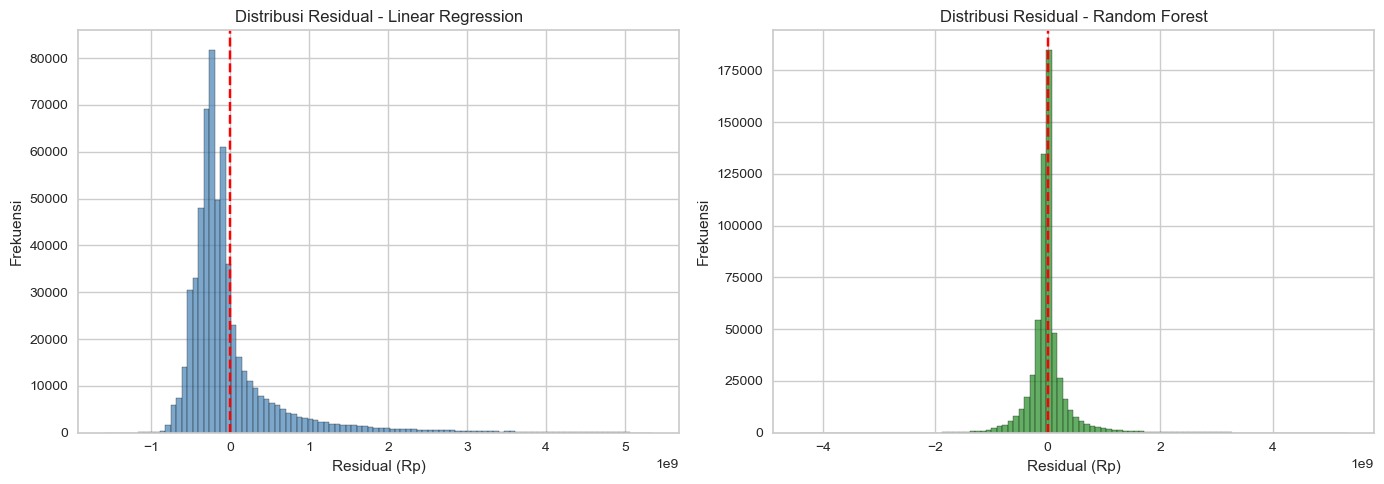

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

residual_lr = y_test - y_pred_lr
residual_rf = y_test - y_pred_rf

axes[0].hist(residual_lr, bins=100, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(x=0, color='red', linestyle='--')
axes[0].set_title('Distribusi Residual - Linear Regression', fontsize=12)
axes[0].set_xlabel('Residual (Rp)')
axes[0].set_ylabel('Frekuensi')

axes[1].hist(residual_rf, bins=100, color='forestgreen', edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--')
axes[1].set_title('Distribusi Residual - Random Forest', fontsize=12)
axes[1].set_xlabel('Residual (Rp)')
axes[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

### 5.4 Feature Importance (Random Forest)

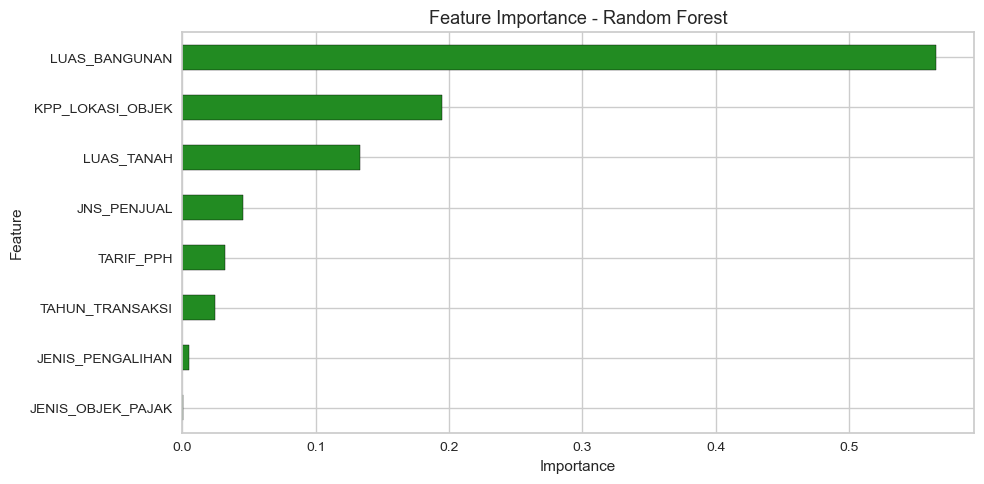


Feature Importance (descending):
  LUAS_BANGUNAN            : 0.5653 (56.5%)
  KPP_LOKASI_OBJEK         : 0.1947 (19.5%)
  LUAS_TANAH               : 0.1335 (13.3%)
  JNS_PENJUAL              : 0.0457 (4.6%)
  TARIF_PPH                : 0.0319 (3.2%)
  TAHUN_TRANSAKSI          : 0.0242 (2.4%)
  JENIS_PENGALIHAN         : 0.0047 (0.5%)
  JENIS_OBJEK_PAJAK        : 0.0001 (0.0%)


In [46]:
feature_names = features_cat + features_num
importances = rf_model.feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=True)

plt.figure(figsize=(10, 5))
feat_imp.plot(kind='barh', color='forestgreen', edgecolor='black')
plt.title('Feature Importance - Random Forest', fontsize=13)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("\nFeature Importance (descending):")
for feat, imp in feat_imp.sort_values(ascending=False).items():
    print(f"  {feat:25s}: {imp:.4f} ({imp*100:.1f}%)")

### 5.5 Perbandingan Metrik dalam Bar Chart

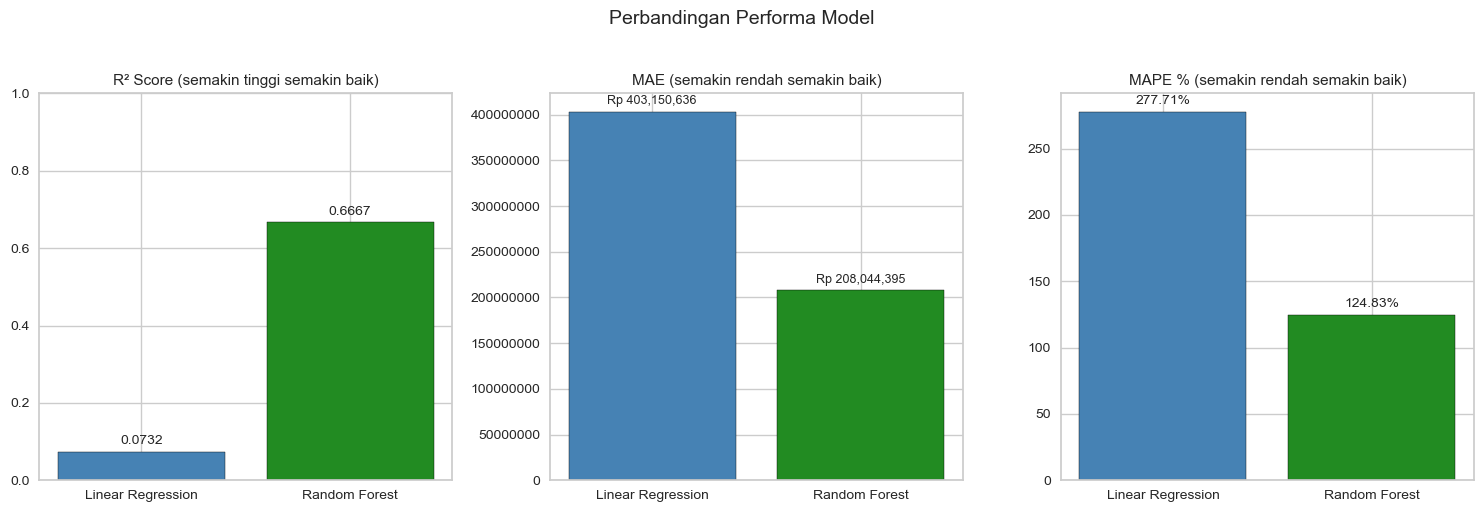

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# R² Score
models = ['Linear Regression', 'Random Forest']
r2_scores = [lr_r2, rf_r2]
bars1 = axes[0].bar(models, r2_scores, color=['steelblue', 'forestgreen'], edgecolor='black')
axes[0].set_title('R² Score (semakin tinggi semakin baik)', fontsize=11)
axes[0].set_ylim(0, 1)
for bar, val in zip(bars1, r2_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                f'{val:.4f}', ha='center', fontsize=10)

# MAE
mae_scores = [lr_mae, rf_mae]
bars2 = axes[1].bar(models, mae_scores, color=['steelblue', 'forestgreen'], edgecolor='black')
axes[1].set_title('MAE (semakin rendah semakin baik)', fontsize=11)
axes[1].ticklabel_format(style='plain', axis='y')
for bar, val in zip(bars2, mae_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(mae_scores)*0.02, 
                f'Rp {val:,.0f}', ha='center', fontsize=9)

# MAPE
mape_scores = [lr_mape, rf_mape]
bars3 = axes[2].bar(models, mape_scores, color=['steelblue', 'forestgreen'], edgecolor='black')
axes[2].set_title('MAPE % (semakin rendah semakin baik)', fontsize=11)
for bar, val in zip(bars3, mape_scores):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(mape_scores)*0.02, 
                f'{val:.2f}%', ha='center', fontsize=10)

plt.suptitle('Perbandingan Performa Model', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## CRISP-DM Phase 6: Deployment & Kesimpulan

### Kesimpulan Hasil Model dan Evaluasi

Evaluasi menunjukkan bahwa **Random Forest** adalah model terbaik untuk kasus prediksi nilai transaksi PHTB pada data ini.

| Aspek Evaluasi | Linear Regression | Random Forest |
|---|---|---|
| **R² (Test Set)** | **0.0730** | **0.5844** |
| **Pola Prediksi vs Aktual** | Banyak titik jauh dari garis ideal; cenderung underfit | Lebih mengikuti pola aktual dan lebih dekat ke garis ideal |
| **Error (RMSE/MAE/MAPE)** | Relatif lebih tinggi | Relatif lebih rendah |
| **Kesiapan Implementasi** | Kurang direkomendasikan sebagai model utama | Akan digunakan sebagai model utama |

### Rekomendasi Penerapan di Direktorat Ekstensifikasi dan Penilaian
1. **Deploy Random Forest** sebagai model utama untuk scoring awal kewajaran nilai transaksi PHTB.
2. **Use case utama**: deteksi transaksi under-valuation. Jika selisih harga aktual terhadap prediksi terlalu besar (residual negatif > 2σ), transaksi di-flag untuk penelitian lanjutan.
3. **Feature utama** (`LUAS_BANGUNAN` dan `LUAS_TANAH`) paling berpengaruh, valid dijadikan fokus quality control data.
4. **Perbaikan berikutnya**: Akan memanfaatkan data lokasi KPP_LOKASI_OBJEK dan Koordinatnya

### Langkah Selanjutnya (Deployment)